In [1]:
import random
import mpmath as mp

mp.mp.dps = 50  # высокая точность

# === параметры задачи ===
v = mp.mpf('10.0')        
alpha = mp.mpf('5.0')
eta_k = mp.mpf('-1') * mp.atan(alpha)
h = mp.mpf('0.55')
gamma = mp.mpf('4.5')

params = (gamma, v, alpha, eta_k, h)

# === функция F(λ) и её производная ===
def F(lmbd, gamma, v, alpha, eta_k, h):
    c = mp.cos(eta_k)
    s = mp.sin(eta_k)
    E = mp.exp(-lmbd * h)
    one_minus_E = 1 - E
    return (
        lmbd**2
        + 2 * lmbd * gamma * c * one_minus_E
        + gamma**2 * one_minus_E**2
        + 2 * (v - gamma * c) * (lmbd + gamma * (c - alpha * s) * one_minus_E)
    )

def dF(lmbd, gamma, v, alpha, eta_k, h):
    c = mp.cos(eta_k)
    s = mp.sin(eta_k)
    E = mp.exp(-lmbd * h)
    one_minus_E = 1 - E
    return (
        2 * lmbd
        + 2 * gamma * c * (one_minus_E + lmbd * h * E)
        + 2 * gamma**2 * one_minus_E * h * E
        + 2 * (v - gamma * c) * (1 + gamma * (c - alpha * s) * h * E)
    )

# === метод Ньютона в комплексной области ===
def newton(z0, params, tol=mp.mpf('1e-25'), itmax=100):
    z = mp.mpc(z0)  

    for _ in range(itmax):
        f = F(z, *params)
        if abs(f) < tol:
            return z

        df = dF(z, *params)
        if abs(df) < mp.mpf('1e-40'):
            return None

        z_new = z - f / df

        if abs(z_new - z) < tol * max(1, abs(z)):
            return z_new

        z = z_new

    return None

def same_root(r1, r2, atol=mp.mpf('1e-10'), rtol=mp.mpf('1e-8')):
    return abs(r1 - r2) <= max(atol, rtol * max(abs(r1), abs(r2)))


def count_roots(F, params, R=20, I=300, n=8000):
    pts = []

    # контур
    for t in mp.linspace(0, R, n):
        pts.append(mp.mpc(t, -I))
    for t in mp.linspace(-I, I, n):
        pts.append(mp.mpc(R, t))
    for t in mp.linspace(R, 0, n):
        pts.append(mp.mpc(t, I))
    for t in mp.linspace(I, -I, n):
        pts.append(mp.mpc(0, t))

    total = mp.mpf('0')
    prev = mp.arg(F(pts[0], *params))

    for z in pts[1:]:
        cur = mp.arg(F(z, *params))
        d = cur - prev

        # более устойчивый unwrap
        while d > mp.pi:
            d -= 2*mp.pi
        while d < -mp.pi:
            d += 2*mp.pi

        total += d
        prev = cur

    return int(round(total / (2*mp.pi)))


# === стартовые точки для поиска корней ===
starts = []

# сетка стартов
for re in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    for im in range(-300, 301, 5):
        starts.append(mp.mpc(re, im))

# случайные старты
rng = random.Random(1)  # фиксируем seed для воспроизводимости
for _ in range(1500):
    re = rng.uniform(0, 10)
    im = rng.uniform(-400, 400)
    starts.append(mp.mpc(re, im))

# === поиск корней ===
roots = []
for z0 in starts:
    r = newton(z0, params)
    if r is None:
        continue

    # оставляем только корни с Re > 0
    if mp.re(r) <= 0:
        continue

    # более строгая проверка невязки
    if abs(F(r, *params)) > mp.mpf('1e-18'):
        continue

    # удаление дублей
    if any(same_root(r, rr) for rr in roots):
        continue

    roots.append(r)

# сортировка
roots = sorted(roots, key=lambda z: (-mp.re(z), abs(mp.im(z))))
N_expected = count_roots(F, params)
print("Ожидаемое число корней:", N_expected)
print("Найдено:", len(roots))

# === вывод ===
print(f"h = {h}, найдено корней с Re > 0: {len(roots)}\n")
for i, r in enumerate(roots, 1):
    val = abs(F(r, *params))
    print(
        f"{i}: λ = {mp.nstr(r, 20)}   "
        f"Re={mp.nstr(mp.re(r), 12)}   "
        f"Im={mp.nstr(mp.im(r), 12)}   "
        f"|F|={mp.nstr(val, 5)}"
    )

Ожидаемое число корней: 4
Найдено: 5
h = 0.55, найдено корней с Re > 0: 5

1: λ = (0.20706470789572898346 + 10.429251354199583538j)   Re=0.207064707896   Im=10.4292513542   |F|=3.8394e-30
2: λ = (0.20706470789572898346 - 10.429251354199583538j)   Re=0.207064707896   Im=-10.4292513542   |F|=9.5624e-49
3: λ = (0.18512658322800173739 - 20.211031571012621581j)   Re=0.185126583228   Im=-20.211031571   |F|=7.2892e-35
4: λ = (0.18512658322800173739 + 20.211031571012621581j)   Re=0.185126583228   Im=20.211031571   |F|=8.471e-39
5: λ = (7.2634820691367136676e-52 + 8.0003009923226968256e-54j)   Re=7.26348206914e-52   Im=8.00030099232e-54   |F|=1.3393e-50


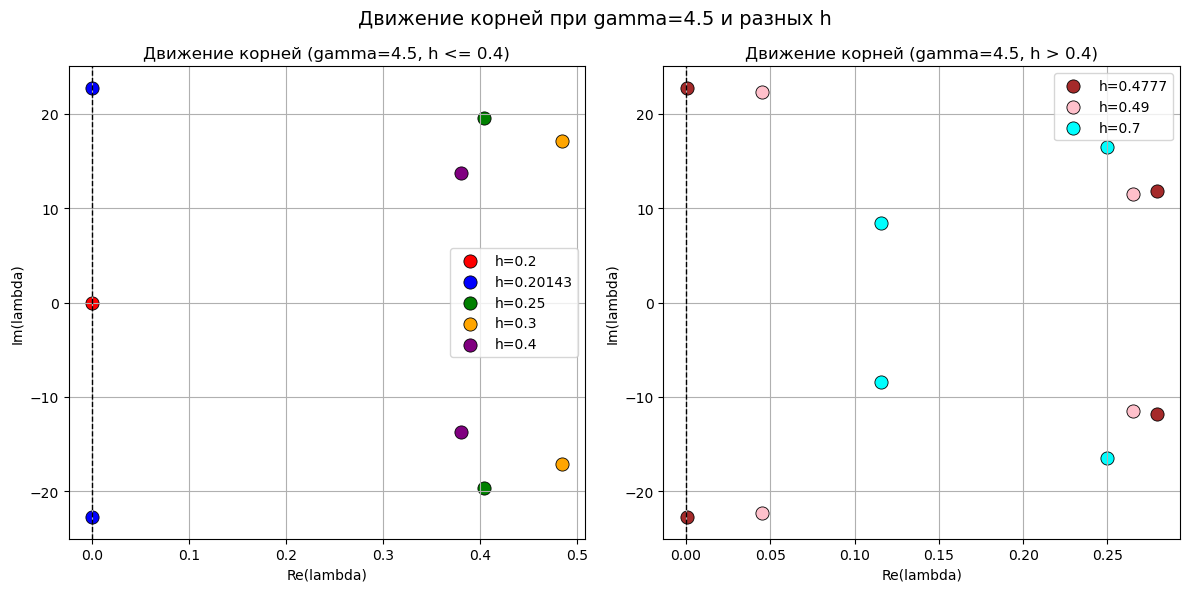

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Исходные данные
roots_dict = {
    0.2: [8.5703523158597873837e-44 - 6.1050380634270023615e-44j],
    0.20143: [0.000017114596848040834447 - 22.755646305814692454j,
              0.000017114596848040834447 + 22.755646305814692454j],
    0.25: [0.40361957491357265547 + 19.604107223534565349j,
           0.40361957491357265547 - 19.604107223534565349j],
    0.3: [0.48391991343098726903 - 17.162297229173178617j,
          0.48391991343098726903 + 17.162297229173178617j],
    0.4: [0.38032542815450132031 + 13.69276904854589178j,
          0.38032542815450132031 - 13.69276904854589178j],
    0.4777: [0.27910374992585599812 + 11.795063234101651403j,
             0.27910374992585599812 - 11.795063234101651403j,
             0.00061106155085432927953 - 22.749486405189025305j,
             0.00061106155085432927953 + 22.749486405189025305j],
    0.49: [0.26524569780569049159 + 11.539332387337249531j,
           0.26524569780569049159 - 11.539332387337249531j,
           0.045128293823342812062 + 22.270627096430018295j,
           0.045128293823342812062 - 22.270627096430018295j],
    0.7: [0.2494869248235034778 - 16.432787577020930419j,
            0.2494869248235034778 + 16.432787577020930419j,
            0.1158108166882686549 + 8.3863532028934909849j,
            0.1158108166882686549 - 8.3863532028934909849j]
}

# Разделяем на h <= 0.4 и h > 0.4
roots_dict1 = {h: roots for h, roots in roots_dict.items() if h <= 0.4}
roots_dict2 = {h: roots for h, roots in roots_dict.items() if h > 0.4}

colors = [
    'red',          
    'blue',         
    'green',        
    'orange',       
    'purple',       
    'brown',        
    'pink',         
    'cyan',         
    'magenta',      
    'lime'          
]
colors1 = colors[:len(roots_dict1)]
colors2 = colors[len(roots_dict1):]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# ---- График 1: h <= 0.4 ----
for (h, roots), color in zip(roots_dict1.items(), colors1):
    roots = np.array(roots)
    ax1.scatter(roots.real, roots.imag,
                s=90, facecolors=color, edgecolors='black',
                linewidths=0.6, label=f'h={h}')

ax1.axvline(0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Re(lambda)')
ax1.set_ylabel('Im(lambda)')
ax1.set_title('Движение корней (gamma=4.5, h <= 0.4)')
ax1.legend()
ax1.grid(True)

# ---- График 2: h > 0.4 ----
for (h, roots), color in zip(roots_dict2.items(), colors2):
    roots = np.array(roots)
    ax2.scatter(roots.real, roots.imag,
                s=90, facecolors=color, edgecolors='black',
                linewidths=0.6, label=f'h={h}')

ax2.axvline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Re(lambda)')
ax2.set_ylabel('Im(lambda)')
ax2.set_title('Движение корней (gamma=4.5, h > 0.4)')
ax2.legend()
ax2.grid(True)

fig.suptitle('Движение корней при gamma=4.5 и разных h', fontsize=14)
plt.tight_layout()
plt.show()

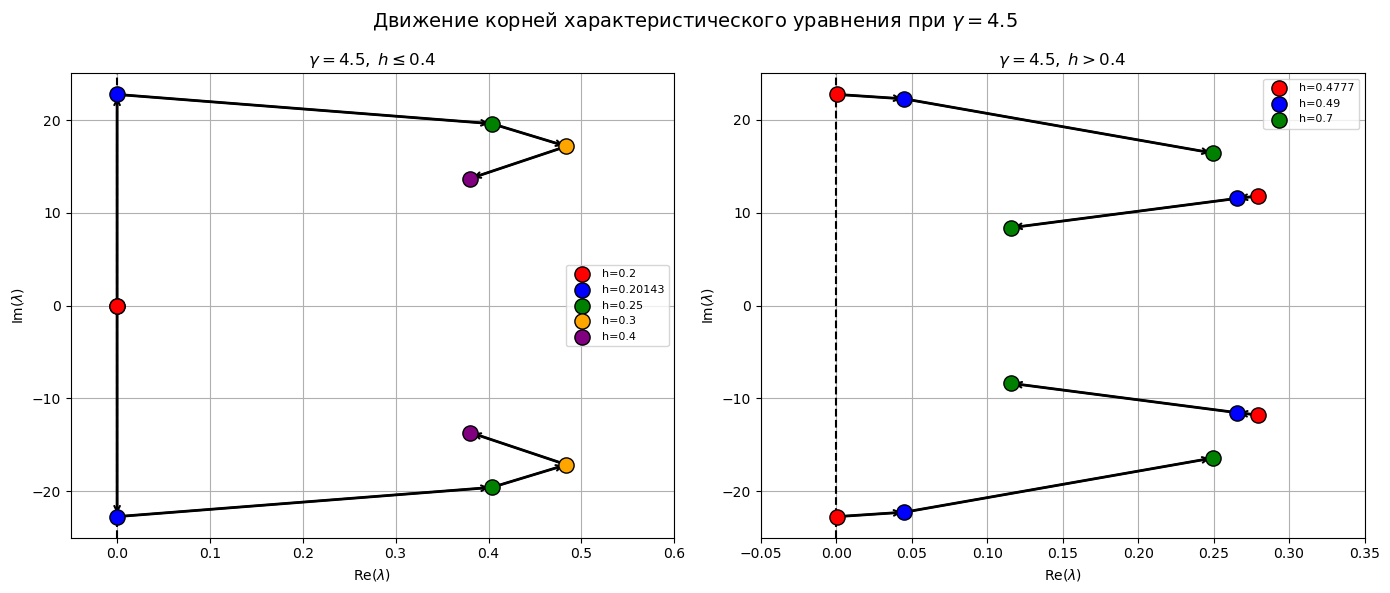

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Цвета для разных h
# =====================================================

colors1 = {
    0.2: 'red',
    0.20143: 'blue',
    0.25: 'green',
    0.3: 'orange',
    0.4: 'purple'
}

colors2 = {
    0.4777: 'red',
    0.49: 'blue',
    0.7: 'green'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# =====================================================
# ЛЕВАЯ КАРТИНКА
# =====================================================

h_track1 = [0.2, 0.20143, 0.25, 0.3, 0.4]

track_pos1 = np.array([
    0 + 0j,
    0.000017114596848040834447 + 22.755646305814692454j,
    0.40361957491357265547 + 19.604107223534565349j,
    0.48391991343098726903 + 17.162297229173178617j,
    0.38032542815450132031 + 13.69276904854589178j
])

track_pos2 = np.array([
    0 + 0j,
    0.000017114596848040834447 - 22.755646305814692454j,
    0.40361957491357265547 - 19.604107223534565349j,
    0.48391991343098726903 - 17.162297229173178617j,
    0.38032542815450132031 - 13.69276904854589178j
])

# линии
ax1.plot(track_pos1.real, track_pos1.imag,
         color='black', lw=2)

ax1.plot(track_pos2.real, track_pos2.imag,
         color='black', lw=2)

# стрелки
for track in [track_pos1, track_pos2]:
    for i in range(len(track)-1):
        ax1.annotate(
            '',
            xy=(track.real[i+1], track.imag[i+1]),
            xytext=(track.real[i], track.imag[i]),
            arrowprops=dict(
                arrowstyle='->',
                color='black',
                lw=1.5
            )
        )

# точки
for i, h in enumerate(h_track1):

    ax1.scatter(
        track_pos1.real[i],
        track_pos1.imag[i],
        s=120,
        color=colors1[h],
        edgecolors='black',
        zorder=5,
        label=f'h={h}'
    )

    ax1.scatter(
        track_pos2.real[i],
        track_pos2.imag[i],
        s=120,
        color=colors1[h],
        edgecolors='black',
        zorder=5
    )

ax1.axvline(0, color='black', linestyle='--')

ax1.set_xlim(-0.05, 0.60)

ax1.set_xlabel(r'Re($\lambda$)')
ax1.set_ylabel(r'Im($\lambda$)')
ax1.set_title(r'$\gamma=4.5,\; h\leq0.4$')

ax1.grid(True)
ax1.legend(fontsize=8)

# =====================================================
# ПРАВАЯ КАРТИНКА
# =====================================================

h_track2 = [0.4777, 0.49, 0.7]

track_pos1 = np.array([
    0.27910374992585599812 + 11.795063234101651403j,
    0.26524569780569049159 + 11.539332387337249531j,
    0.1158108166882686549 + 8.3863532028934909849j
])

track_pos2 = np.array([
    0.27910374992585599812 - 11.795063234101651403j,
    0.26524569780569049159 - 11.539332387337249531j,
    0.1158108166882686549 - 8.3863532028934909849j
])

track_pos3 = np.array([
    0.00061106155085432927953 + 22.749486405189025305j,
    0.045128293823342812062 + 22.270627096430018295j,
    0.2494869248235034778 + 16.432787577020930419j
])

track_pos4 = np.array([
    0.00061106155085432927953 - 22.749486405189025305j,
    0.045128293823342812062 - 22.270627096430018295j,
    0.2494869248235034778 - 16.432787577020930419j
])

# линии
for track in [track_pos1, track_pos2, track_pos3, track_pos4]:

    ax2.plot(
        track.real,
        track.imag,
        color='black',
        lw=2
    )

    for i in range(len(track)-1):
        ax2.annotate(
            '',
            xy=(track.real[i+1], track.imag[i+1]),
            xytext=(track.real[i], track.imag[i]),
            arrowprops=dict(
                arrowstyle='->',
                color='black',
                lw=1.5
            )
        )

# точки
for i, h in enumerate(h_track2):

    color = colors2[h]

    for track in [track_pos1, track_pos2,
                  track_pos3, track_pos4]:

        ax2.scatter(
            track.real[i],
            track.imag[i],
            s=120,
            color=color,
            edgecolors='black',
            zorder=5
        )

    # элемент легенды
    ax2.scatter(
        [],
        [],
        s=120,
        color=color,
        edgecolors='black',
        label=f'h={h}'
    )

ax2.axvline(0, color='black', linestyle='--')

ax2.set_xlim(-0.05, 0.35)

ax2.set_xlabel(r'Re($\lambda$)')
ax2.set_ylabel(r'Im($\lambda$)')
ax2.set_title(r'$\gamma=4.5,\; h>0.4$')

ax2.grid(True)
ax2.legend(fontsize=8)

# =====================================================

fig.suptitle(
    r'Движение корней характеристического уравнения при $\gamma=4.5$',
    fontsize=14
)

plt.tight_layout()
plt.show()